# Forward models and receivers

In seismo-sbi a forward model is a `Simulator`: it takes a dictionary of source parameters
and returns the seismograms at every receiver, as `{station: {component: trace}}`. This
notebook builds the receivers, runs the three families of forward model the library ships
(Instaseis, a linearised kernel model, and Computer Programs in Seismology), plugs in a
forward model of our own, and attaches the post-processing chain that adds nuisance effects.

**Requirements**: `INSTASEIS_DB` pointing at a local Instaseis database (the 10 s PREM
database is enough) and `CPS_PATH` pointing at the `bin/` directory of a Computer Programs in
Seismology installation. Nothing is downloaded. The notebook runs in well under a minute.

In [1]:
import os
import tempfile
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

INSTASEIS_DB = os.environ["INSTASEIS_DB"]
CPS_PATH = os.environ["CPS_PATH"]
SAMPLING_RATE_HZ = 1.0
DURATION_S = 200
PROCESSING = {"filter": {"type": "bandpass", "freqmin": 0.02, "freqmax": 0.08,
                         "corners": 4, "zerophase": False},
              "sampling_rate": SAMPLING_RATE_HZ, "filter_sampling_rate": 5.0}
SOURCE = {"source_location": [37.636, -118.936, 10.0, 0.0],  # latitude, longitude, depth_km, time shift s
          "moment_tensor": [1.0e17, -0.6e17, -0.4e17, 0.3e17, -0.5e17, 0.2e17]}  # m_rr, m_tt, m_pp, m_rt, m_rp, m_tp (N m)
scratch = Path(tempfile.mkdtemp())

## Receivers

`Receivers` is an ordered set of stations; that order is the order of every seismogram array
in the pipeline. It is built from a station file (`name network latitude longitude`, with an
optional JSON map of the components each station records), from arrays, or from an obspy
`Inventory` read from StationXML.

In [2]:
from obspy.core.inventory import Inventory, Network, Station
from seismo_sbi.simulators.receivers import Receivers

receivers = Receivers.from_station_file("configs/stations.txt")
print(receivers)
print("station locations (latitude, longitude):\n", receivers.get_station_locations_array())

array_receivers = Receivers.from_arrays(["A01", "A02"], ["XX", "XX"], [37.0, 38.0], [-118.0, -119.5],
                                        components=["Z"])
print(array_receivers, [receiver.components for receiver in array_receivers])

inventory = Inventory(networks=[Network("BK", stations=[
    Station("PKD", latitude=35.945171, longitude=-120.541603, elevation=583.0)])])
print(Receivers.from_inventory(inventory))

Receivers(5 stations: BKS, CMB, KCC, ORV, PKD)
station locations (latitude, longitude):
 [[  37.876221 -122.23558 ]
 [  38.03455  -120.386513]
 [  37.323631 -119.318703]
 [  39.554508 -121.500359]
 [  35.945171 -120.541603]]
Receivers(2 stations: A01, A02) [['Z'], ['Z']]
Receivers(1 stations: PKD)


## Instaseis

`InstaseisSourceSimulator` extracts seismograms from a precomputed Instaseis database, filters
them at `filter_sampling_rate` (the rate your observed data are filtered at, so both see the
same filter) and resamples them as `synthetics_processing` asks. Its traces start
`SYNTHETICS_PRE_EVENT_PAD_S` (60 s) before the origin, like the windows cut from recorded data.

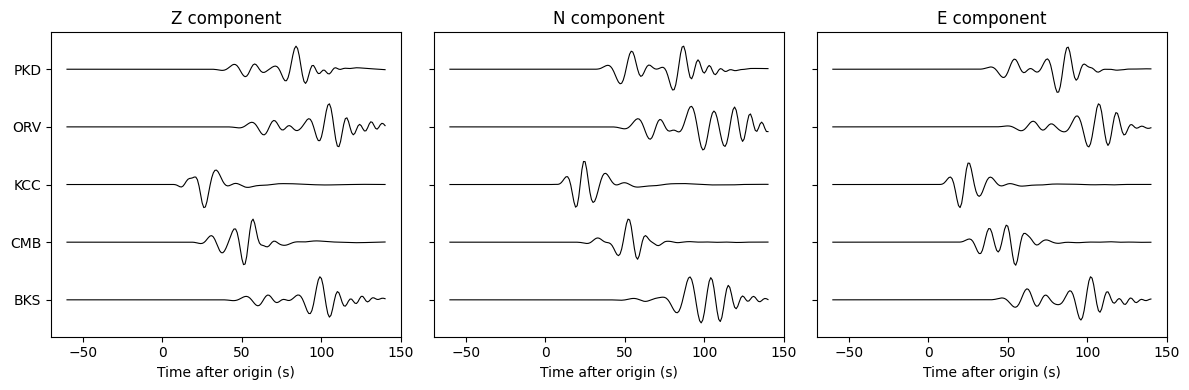

BKS peak |Z| = 2.5775e-05 m
CMB peak |Z| = 3.5404e-05 m
KCC peak |Z| = 1.0185e-04 m
ORV peak |Z| = 1.5344e-05 m
PKD peak |Z| = 3.7014e-05 m


In [3]:
from seismo_sbi.simulators.instaseis.querier import SYNTHETICS_PRE_EVENT_PAD_S
from seismo_sbi.simulators.instaseis.simulator import InstaseisSourceSimulator

instaseis_simulator = InstaseisSourceSimulator(
    INSTASEIS_DB, components="ZNE", receivers=receivers,
    seismogram_duration_in_s=DURATION_S, synthetics_processing=PROCESSING)
source, seismograms = instaseis_simulator.run_simulation(SOURCE)

time_s = np.arange(len(seismograms["PKD"]["Z"])) / SAMPLING_RATE_HZ - SYNTHETICS_PRE_EVENT_PAD_S
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for ax, component in zip(axes, "ZNE"):
    for offset, station in enumerate(seismograms):
        trace = seismograms[station][component]
        ax.plot(time_s, trace / np.abs(trace).max() * 0.4 + offset, "k", lw=0.8)
    ax.set_title(f"{component} component")
    ax.set_xlabel("Time after origin (s)")
axes[0].set_yticks(range(len(seismograms)), list(seismograms))
plt.tight_layout()
plt.show()

for station in seismograms:
    print(station, "peak |Z| =", f"{np.abs(seismograms[station]['Z']).max():.4e}", "m")

## The linearised kernel model

At a fixed source location the seismograms are linear in the six moment-tensor components,
$d = G^\mathsf{T} m$. Running Instaseis once per unit moment tensor gives the sensitivity kernels
$G$, shape `(6, n_data)`, flattened in receiver and component order by `SimulationDataLoader`.
`FixedLocationKernelSimulator` then replaces each wavefield extraction by one matrix product;
it is what the pipeline uses to generate large training sets. (The pipeline computes $G$ by
finite differences around a fiducial source, which is exact for a linear model.)

In [4]:
from seismo_sbi.sbi.compression.gaussian import ScoreCompressionData
from seismo_sbi.simulators.kernel import FixedLocationKernelSimulator
from seismo_sbi.simulators.simulation_io import SimulationDataLoader, seismogram_map_to_array

data_loader = SimulationDataLoader("ZEN", receivers)




unit_tensors = np.eye(6) * 1e17
kernels = np.array([seismogram_map_to_array(instaseis_simulator.run_simulation(
    {**SOURCE, "moment_tensor": list(unit)})[1], receivers) for unit in unit_tensors]) / 1e17
print("kernel shape (n_moment_tensor_components, n_data):", kernels.shape)

kernel_simulator = FixedLocationKernelSimulator(
    ScoreCompressionData(theta_fiducial=np.zeros(6), data_fiducial=np.zeros(kernels.shape[1]),
                         data_parameter_gradients=kernels, second_order_gradients=None),
    components="ZNE", receivers=receivers, seismogram_duration_in_s=DURATION_S,
    synthetics_processing=PROCESSING)

start = time.perf_counter()
kernel_data = seismogram_map_to_array(kernel_simulator.run_simulation(SOURCE)[1], receivers)
kernel_time_s = time.perf_counter() - start
start = time.perf_counter()
instaseis_data = seismogram_map_to_array(instaseis_simulator.run_simulation(SOURCE)[1], receivers)
instaseis_time_s = time.perf_counter() - start
relative_difference = np.abs(kernel_data - instaseis_data).max() / np.abs(instaseis_data).max()
assert relative_difference < 1e-10
print("kernel model and Instaseis agree to better than 1e-10 of the peak amplitude")
print(f"one simulation: Instaseis {instaseis_time_s * 1e3:.2f} ms, kernel model {kernel_time_s * 1e3:.2f} ms")

kernel shape (n_moment_tensor_components, n_data): (6, 3015)
kernel model and Instaseis agree to better than 1e-10 of the peak amplitude
one simulation: Instaseis 198.43 ms, kernel model 0.74 ms


## Computer Programs in Seismology

`CPSVariableKernelSimulator` computes Green's functions for whatever layered model it is handed
as the `velocity_model` source parameter, shape `(6, n_layers)`: thickness (km), $V_P$,
$V_S$ (km/s), density (g/cm³), $Q_P$, $Q_S$. Its traces start at the origin. Here we compare
the Southern California model with a copy whose layer velocities and thicknesses are
perturbed by 5 %, the kind of perturbation the theory-error ensembles are built from.

layer V_S (km/s), reference: [3.18 3.64 3.87 4.5 ]  perturbed: [3.16 3.71 3.9  4.83]


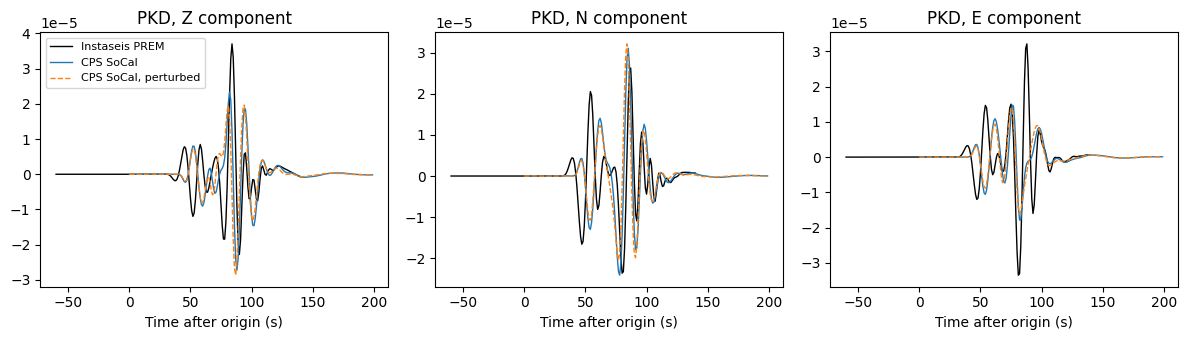

In [5]:
from seismo_sbi.simulators.cps.compatibility import load_velocity_model
from seismo_sbi.simulators.cps.CPS import perturb_model
from seismo_sbi.simulators.cps.simulator import CPSVariableKernelSimulator

socal_model = load_velocity_model("configs/SoCal.plain.txt")
np.random.seed(0)
perturbed_model = perturb_model(socal_model, kappa=5)
print("layer V_S (km/s), reference:", socal_model[2], " perturbed:", perturbed_model[2].round(2))

cps_simulator = CPSVariableKernelSimulator(
    components="ZNE", receivers=receivers, seismogram_duration_in_s=DURATION_S,
    synthetics_processing=PROCESSING, gf_storage_root=str(scratch / "cps"), cps_path=CPS_PATH)
cps_reference = cps_simulator.run_simulation({**SOURCE, "velocity_model": socal_model})[1]
cps_perturbed = cps_simulator.run_simulation({**SOURCE, "velocity_model": perturbed_model})[1]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, component in zip(axes, "ZNE"):
    for label, seismogram_map, style in [("Instaseis PREM", seismograms, "k"),
                                         ("CPS SoCal", cps_reference, "C0"),
                                         ("CPS SoCal, perturbed", cps_perturbed, "C1--")]:
        trace = seismogram_map["PKD"][component]
        start_s = -SYNTHETICS_PRE_EVENT_PAD_S if seismogram_map is seismograms else 0.0
        ax.plot(start_s + np.arange(len(trace)) / SAMPLING_RATE_HZ, trace, style, lw=1, label=label)
    ax.set_title(f"PKD, {component} component")
    ax.set_xlabel("Time after origin (s)")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

## Plugging in your own forward model

Any code that turns a point source into seismograms can join the library: subclass
`Simulator`, implement `generic_point_source_simulation`, and register a builder under a new
`simulation_type` with `register_simulator`. The pipeline then builds it from a configuration
exactly as it builds the shipped ones, and time shifts, the post-processing chain and dataset
generation come for free.

As a toy we take the far-field P wave in a homogeneous whole space (Aki & Richards, eq. 4.29),

$$u(\mathbf{x}, t) = \frac{(\boldsymbol\gamma^\mathsf{T} M \boldsymbol\gamma)\,\boldsymbol\gamma}{4\pi\rho\alpha^3 r}\,\dot s\!\left(t - \frac{r}{\alpha}\right),$$

with $\boldsymbol\gamma$ the unit vector from source to receiver and $\dot s$ a Gaussian
moment-rate pulse of unit area.

In [6]:
from obspy.geodetics import gps2dist_azimuth
from seismo_sbi.sbi.types.parameters import SimulationParameters
from seismo_sbi.simulators.base import Simulator
from seismo_sbi.simulators.registry import build_simulator, register_simulator


class HomogeneousPWaveSimulator(Simulator):
    """Far-field P wave in a homogeneous whole space, as displacement in metres."""

    p_velocity_m_s = 6000.0
    density_kg_m3 = 2700.0
    pulse_width_s = 4.0

    def generic_point_source_simulation(self, source, **kwargs):
        location = source.source_location
        m_rr, m_tt, m_pp, m_rt, m_rp, m_tp = source.moment_tensor.components
        moment_tensor = np.array([[m_rr, m_rt, m_rp], [m_rt, m_tt, m_tp], [m_rp, m_tp, m_pp]])
        time_s = np.arange(int(self.seismogram_length * SAMPLING_RATE_HZ) + 1) / SAMPLING_RATE_HZ
        seismograms = {}
        for receiver in self.receivers.iterate():
            epicentral_m, azimuth_deg, _ = gps2dist_azimuth(location.latitude, location.longitude,
                                                            receiver.latitude, receiver.longitude)
            azimuth = np.radians(azimuth_deg)
            ray = np.array([location.depth * 1e3, -epicentral_m * np.cos(azimuth),
                            epicentral_m * np.sin(azimuth)])  # up, south, east
            distance_m = np.linalg.norm(ray)
            gamma = ray / distance_m
            arrival_s = distance_m / self.p_velocity_m_s
            moment_rate = np.exp(-0.5 * ((time_s - arrival_s) / self.pulse_width_s) ** 2) \
                / (self.pulse_width_s * np.sqrt(2 * np.pi))
            amplitude = gamma @ moment_tensor @ gamma / (
                4 * np.pi * self.density_kg_m3 * self.p_velocity_m_s ** 3 * distance_m)
            up, south, east = amplitude * gamma[:, None] * moment_rate
            seismograms[receiver.station_name] = {"Z": up, "N": -south, "E": east}
        return seismograms


def build_homogeneous_p_wave(simulation_parameters, simulator_config, post_processing_effects,
                             data_flattening):
    return HomogeneousPWaveSimulator(
        components=simulation_parameters.components, receivers=simulation_parameters.receivers,
        seismogram_duration_in_s=simulation_parameters.seismogram_duration,
        synthetics_processing=simulation_parameters.processing,
        post_processing_effects=post_processing_effects)


register_simulator("homogeneous_p_wave", build_homogeneous_p_wave)
simulation_parameters = SimulationParameters(
    receivers=receivers, components="ZNE", seismogram_duration=DURATION_S, syngine_address=None,
    sampling_rate=SAMPLING_RATE_HZ, processing=PROCESSING, simulation_type="homogeneous_p_wave")
toy_simulator = build_simulator((simulation_parameters.simulation_type, None), simulation_parameters)
toy_seismograms = toy_simulator.run_simulation(SOURCE)[1]
for station in toy_seismograms:
    print(station, "peak |Z| =", f"{np.abs(toy_seismograms[station]['Z']).max():.4e}", "m")

BKS peak |Z| = 5.1783e-08 m
CMB peak |Z| = 1.7296e-07 m
KCC peak |Z| = 2.2698e-06 m
ORV peak |Z| = 4.0710e-08 m
PKD peak |Z| = 1.6240e-07 m


Because the toy model is linear in the moment tensor too, flipping the sign of the source
flips every trace, and doubling it doubles them:

In [7]:
toy_data = seismogram_map_to_array(toy_seismograms, receivers)
flipped = seismogram_map_to_array(toy_simulator.run_simulation(
    {**SOURCE, "moment_tensor": list(-2 * np.array(SOURCE["moment_tensor"]))})[1], receivers)
print("d(-2m) equals -2 d(m):", np.abs(flipped + 2 * toy_data).max() < 1e-12 * np.abs(toy_data).max())

d(-2m) equals -2 d(m): True


## The post-processing chain

Every source parameter the forward model does not consume (anything other than the location,
moment tensor, magnitude, velocity model and source-time-function duration) is handed to the
simulator's post-processing chain, which applies nuisance effects to the finished seismograms.
Each effect reads its own key: here `time_shift_error` and `amplitude_error` are the
probabilities that a station is shifted or rescaled. The
[nuisance parameter demo](nuisance_parameters_demo.ipynb) goes through every effect in turn.

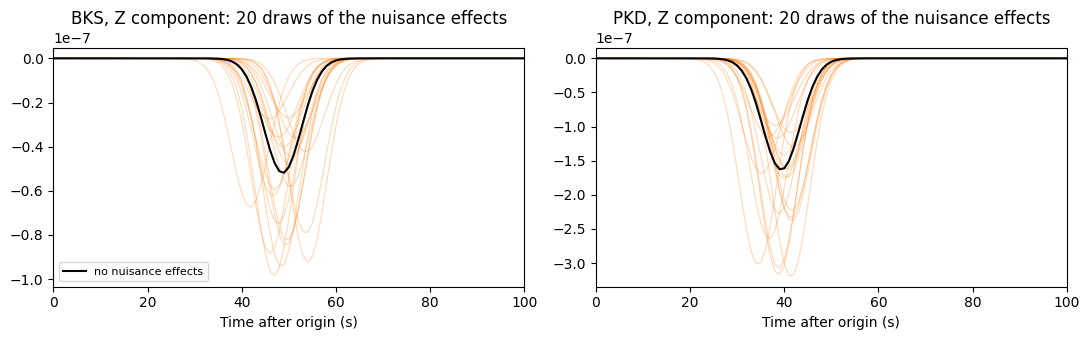

In [8]:
from seismo_sbi.nuisance_effects.amplitude_effect import AmplitudeErrorEffect
from seismo_sbi.nuisance_effects.time_shift_effect import TimeShiftErrorEffect

nuisance_simulator = build_simulator(
    ("homogeneous_p_wave", None), simulation_parameters,
    post_processing_effects=[TimeShiftErrorEffect(sampling_rate=SAMPLING_RATE_HZ, gaussian_sigma=3.0),
                             AmplitudeErrorEffect(scale_range=(0.5, 2.0))])
np.random.seed(1)
realisations = [nuisance_simulator.run_simulation(
    {**SOURCE, "time_shift_error": 1.0, "amplitude_error": 1.0})[1] for _ in range(20)]

time_s = np.arange(len(toy_seismograms["PKD"]["Z"])) / SAMPLING_RATE_HZ
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, station in zip(axes, ["BKS", "PKD"]):
    for realisation in realisations:
        ax.plot(time_s, realisation[station]["Z"], color="C1", alpha=0.3, lw=0.8)
    ax.plot(time_s, toy_seismograms[station]["Z"], "k", lw=1.5, label="no nuisance effects")
    ax.set_xlim(0, 100)
    ax.set_title(f"{station}, Z component: 20 draws of the nuisance effects")
    ax.set_xlabel("Time after origin (s)")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

## Saving and loading simulations

The dataset generator writes each simulation to HDF5 through `execute_sim_and_save_outputs`,
and `SimulationDataLoader` reads it back as a flat data vector or as an array of shape
`(n_stations, n_components, n_samples)`.

In [9]:
path = scratch / "example_simulation.h5"
toy_simulator.execute_sim_and_save_outputs(SOURCE, str(path))
print("inputs:", data_loader.load_input_data(path)["moment_tensor"])
stacked = data_loader.convert_sim_data_to_array(
    {"outputs": toy_seismograms}, stacked=True)
print("stacked shape (n_stations, n_components, n_samples):", stacked.shape)
print("round trip exact:", np.array_equal(data_loader.load_flattened_simulation_vector(path), toy_data))

inputs: {'m_pp': -4e+16, 'm_rp': -5e+16, 'm_rr': 1e+17, 'm_rt': 3e+16, 'm_tp': 2e+16, 'm_tt': -6e+16}
stacked shape (n_stations, n_components, n_samples): (5, 3, 201)
round trip exact: True
